# Phase 3 — core order-flow features: visual sanity

One full dev-slice session (2026-01-06, front contract), features sampled at 1 Hz through the SAME streaming step() used live (Critical Rule 3). Each section states what a sane plot looks like — regenerate with `scripts/build_phase3_visual_notebook.py` after any formula change.

In [1]:
import datetime as dt, sys
sys.path.insert(0, '/home/43e3/solr-home/GC/src')
import numpy as np, pandas as pd
import matplotlib
import matplotlib.pyplot as plt
matplotlib.rcParams.update({"figure.figsize": (14, 3.2), "figure.dpi": 90,
                             "axes.grid": True, "grid.alpha": 0.3})

from features.core_features import FeatureEngine
from features.flow_stream import replay_session_flow
from utilities.config import load_config

CFG = load_config()
SESSION = dt.date.fromisoformat("2026-01-06")
fs = replay_session_flow(SESSION, CFG)
fe = FeatureEngine(CFG)
names, rows = fe.run(fs.cols, sample_every_ns=1_000_000_000)  # 1 Hz view
df = pd.DataFrame(rows)
df["t"] = pd.to_datetime(df["ts"].astype("int64"), utc=True)
df = df.set_index("t")
print(f"{fs.symbol} {SESSION}: {fs.rows:,} groups -> {len(df):,} sampled rows")


GCG6 2026-01-06: 2,696,767 groups -> 61,144 sampled rows


In [2]:
def panel(cols, title, price=True, **kw):
    n = len(cols) + (1 if price else 0)
    fig, axes = plt.subplots(n, 1, sharex=True, figsize=(14, 2.2 * n))
    axes = np.atleast_1d(axes)
    k = 0
    if price:
        axes[0].plot(df.index, df["mid_ticks"] * 0.1, lw=0.7, color="black")
        axes[0].set_ylabel("mid (pts)")
        k = 1
    for i, c in enumerate(cols):
        ax = axes[k + i]
        if isinstance(c, (list, tuple)):
            for cc in c:
                ax.plot(df.index, df[cc], lw=0.7, label=cc)
            ax.legend(loc="upper right", fontsize=8)
        else:
            ax.plot(df.index, df[c], lw=0.7)
            ax.set_ylabel(c, fontsize=8)
    axes[0].set_title(title)
    plt.tight_layout(); plt.show()


## Step 7 — Aggressive Delta (T-only)

Sanity: delta tracks visible directional pushes in mid; the ratio stays in [-1,1]; short window is noisier than long.

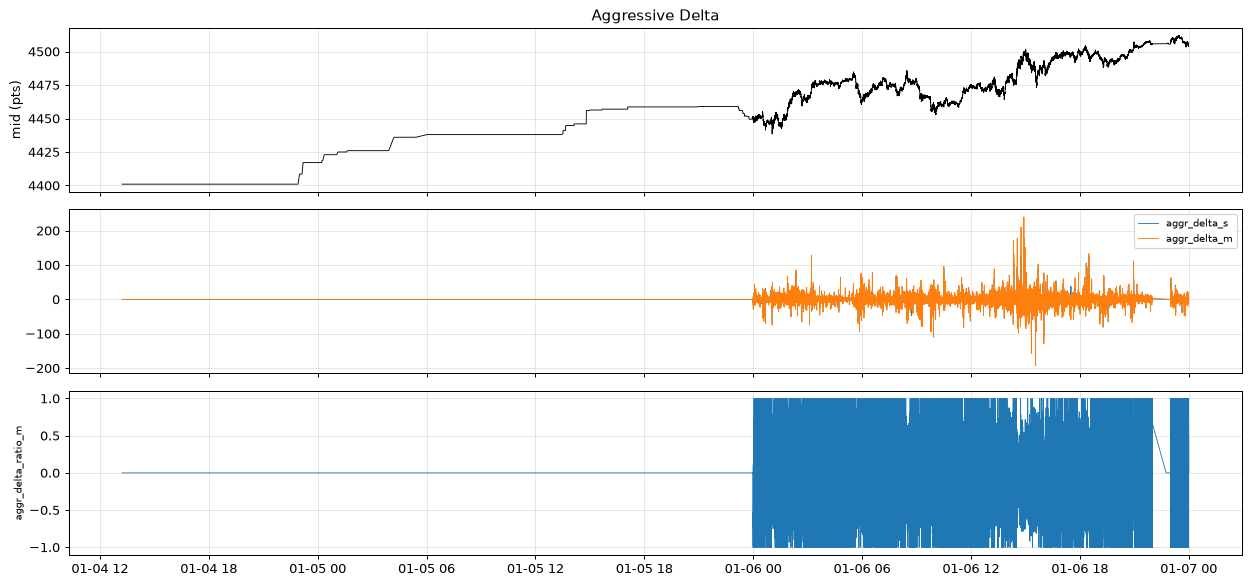

In [3]:
panel([("aggr_delta_s","aggr_delta_m"), "aggr_delta_ratio_m"], "Aggressive Delta")

## Step 8 — Replenishment

Sanity: values hug [0,1] with 0.5 neutral; dips align with one-sided consumption episodes.

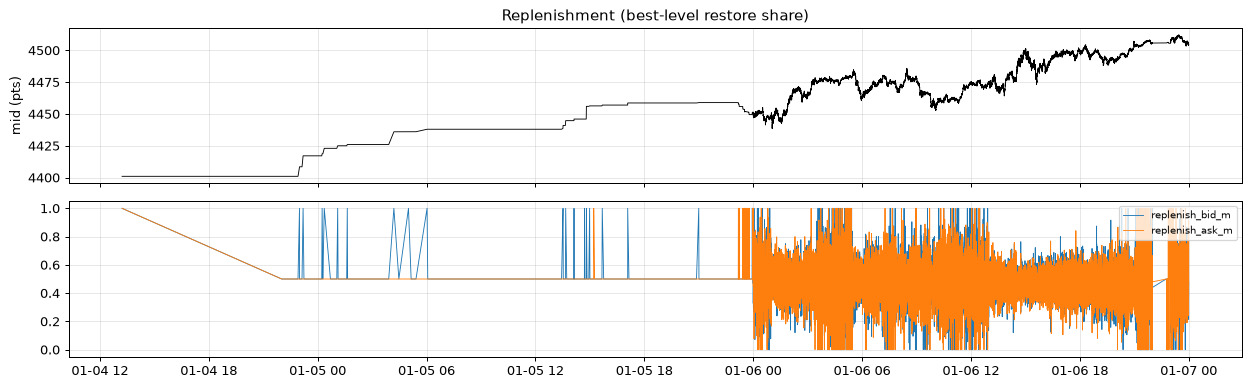

In [4]:
panel([("replenish_bid_m","replenish_ask_m")], "Replenishment (best-level restore share)")

## Step 9 — Price Progress + directional efficiency

Sanity: progress mirrors mid changes; efficiency spikes only in clean directional runs.

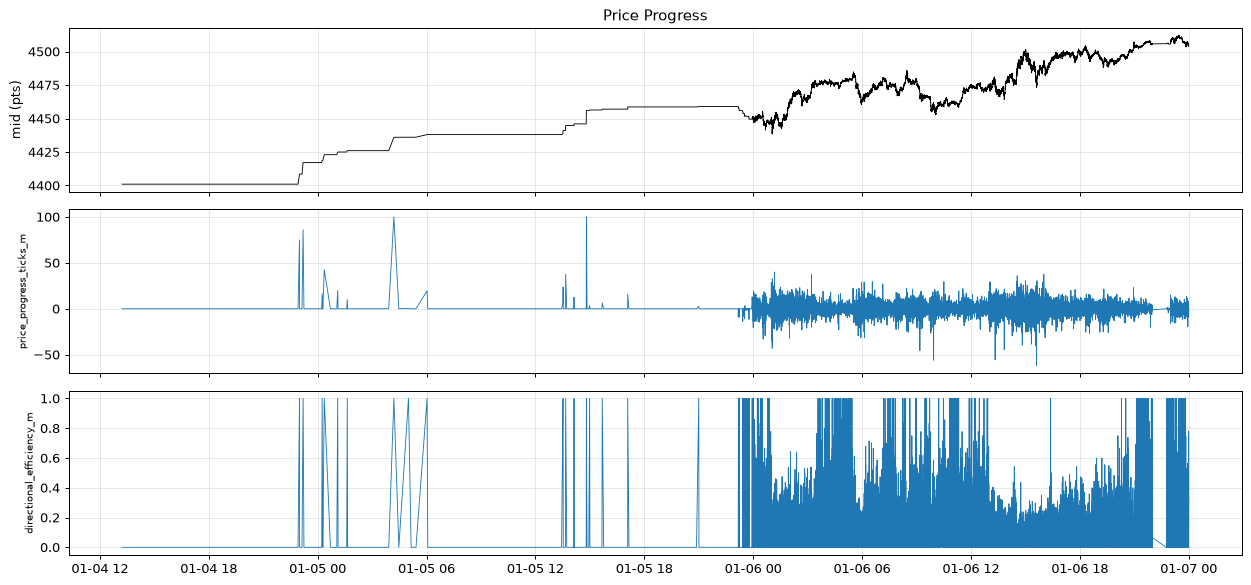

In [5]:
panel(["price_progress_ticks_m", "directional_efficiency_m"], "Price Progress")

## Step 10/11 — ABSORPTION (visual + numeric gate)

Sanity (plan Step 11): absorption should flare when heavy one-sided volume meets a stalling price with a holding/replenishing book — typically at local extremes — and stay near 0 in drifting markets. The numeric check below asserts the top-decile absorption moments have below-median short-window price movement despite above-median volume.

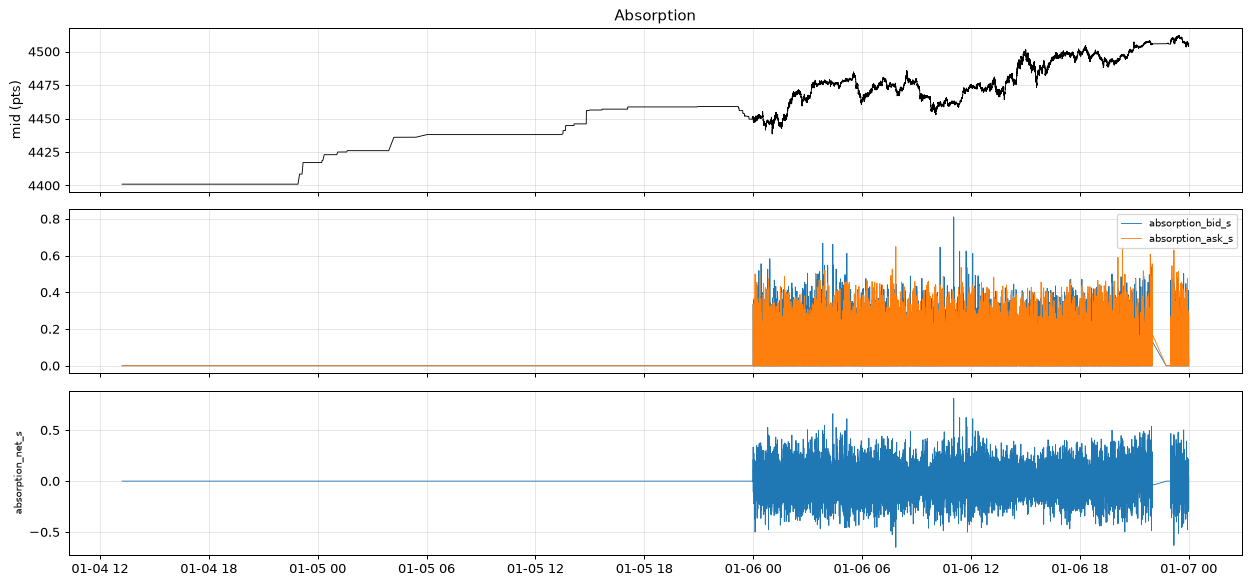

top-decile absorption rows: 6115
median |Δmid 2s| at high absorption: 0.50 ticks vs overall 1.00


In [6]:
panel([("absorption_bid_s","absorption_ask_s"), "absorption_net_s"], "Absorption")
vol = df["aggr_delta_s"].abs() + 2 * np.minimum(df["absorption_bid_s"], 1)  # display aid
absmax = df[["absorption_bid_s","absorption_ask_s"]].max(axis=1)
top = absmax >= absmax.quantile(0.9)
tv = (fs.cols["t_buy"] + fs.cols["t_sell"]).astype(float)
print("top-decile absorption rows:", int(top.sum()))
move_top = df.loc[top, "price_progress_ticks_s"].abs().median()
move_all = df["price_progress_ticks_s"].abs().median()
print(f"median |Δmid 2s| at high absorption: {move_top:.2f} ticks vs overall {move_all:.2f}")
assert move_top <= max(move_all, 1.0), "absorption flags moving markets — review formula"

## Pulling / Stacking (near-touch net flow)

Sanity: bounded [-1,1]; bid stacking episodes should accompany supportive (rising/holding) mid behavior and vice versa.

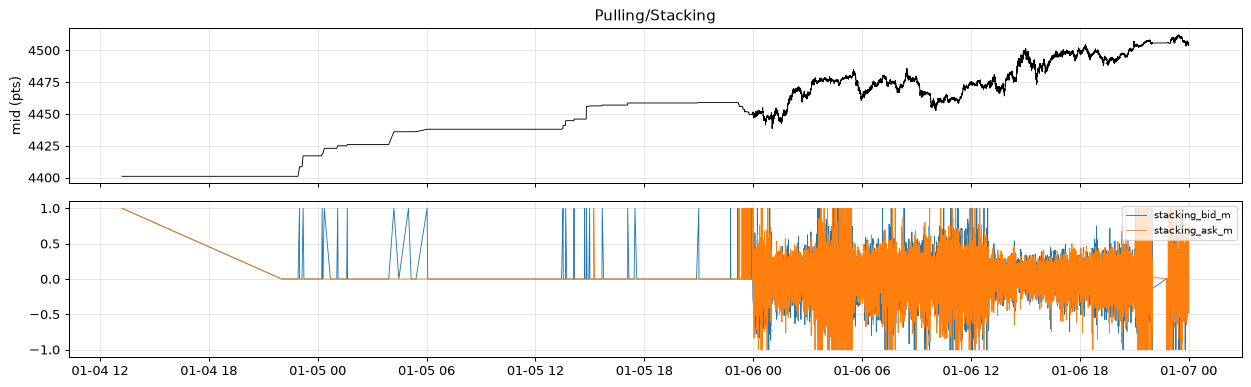

In [7]:
panel([("stacking_bid_m","stacking_ask_m")], "Pulling/Stacking")

## Price Impact

Sanity: non-negative, spikes when small volume moves price (thin conditions), compresses during heavy two-way trade.

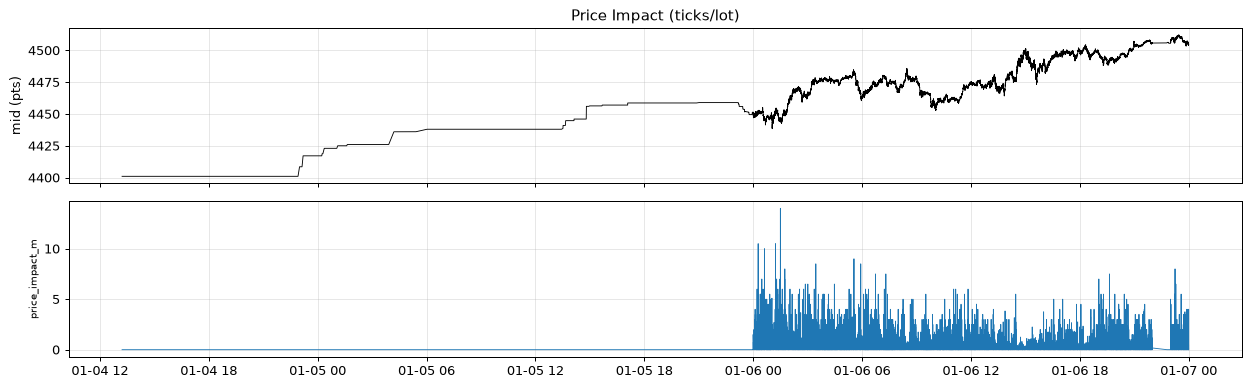

In [8]:
panel(["price_impact_m"], "Price Impact (ticks/lot)")

## MLOFI (levels 1-10: near / middle / deep)

Sanity: signed, near-band most active; deep band slower.

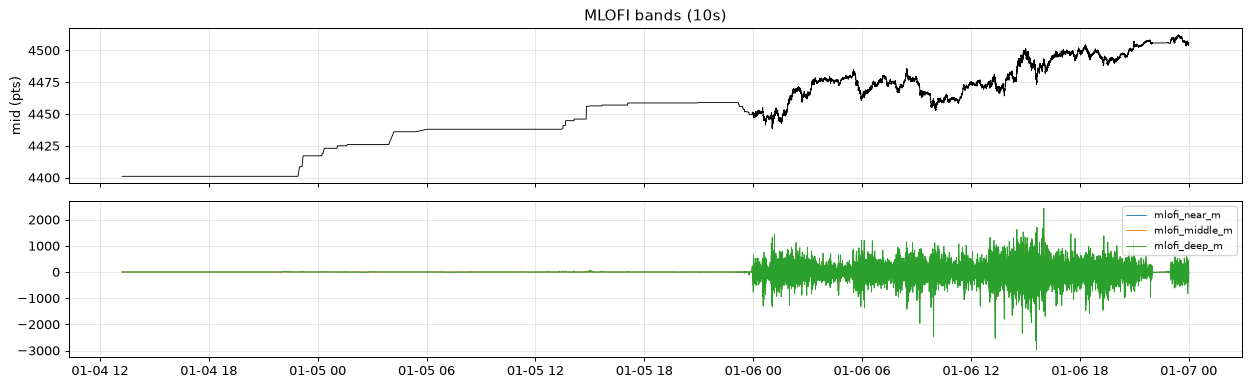

In [9]:
panel([("mlofi_near_m","mlofi_middle_m","mlofi_deep_m")], "MLOFI bands (10s)")

## Book Imbalance + Microprice displacement

Sanity: both signed and mean-reverting around 0; microprice displacement bounded by ~half the spread.

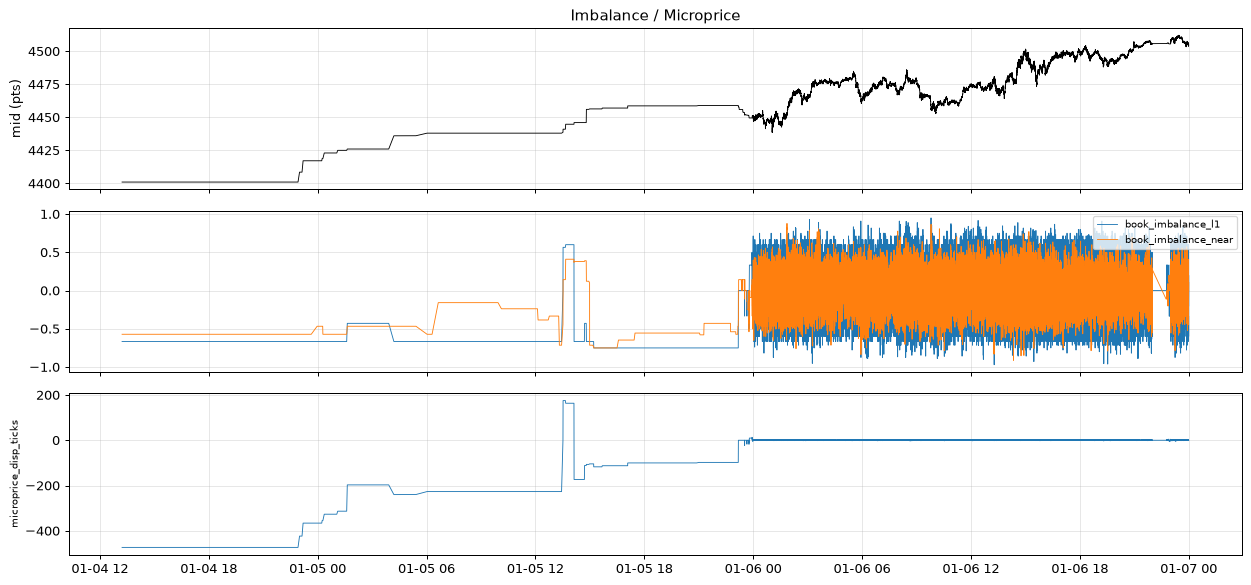

In [10]:
panel([("book_imbalance_l1","book_imbalance_near"), "microprice_disp_ticks"], "Imbalance / Microprice")

## Liquidity Sweep + Sweep Failure/Reclaim

Sanity: sweeps are sparse spikes; failure score lives in [0,1] and decays after the reclaim window; failed-sweep count is a step function.

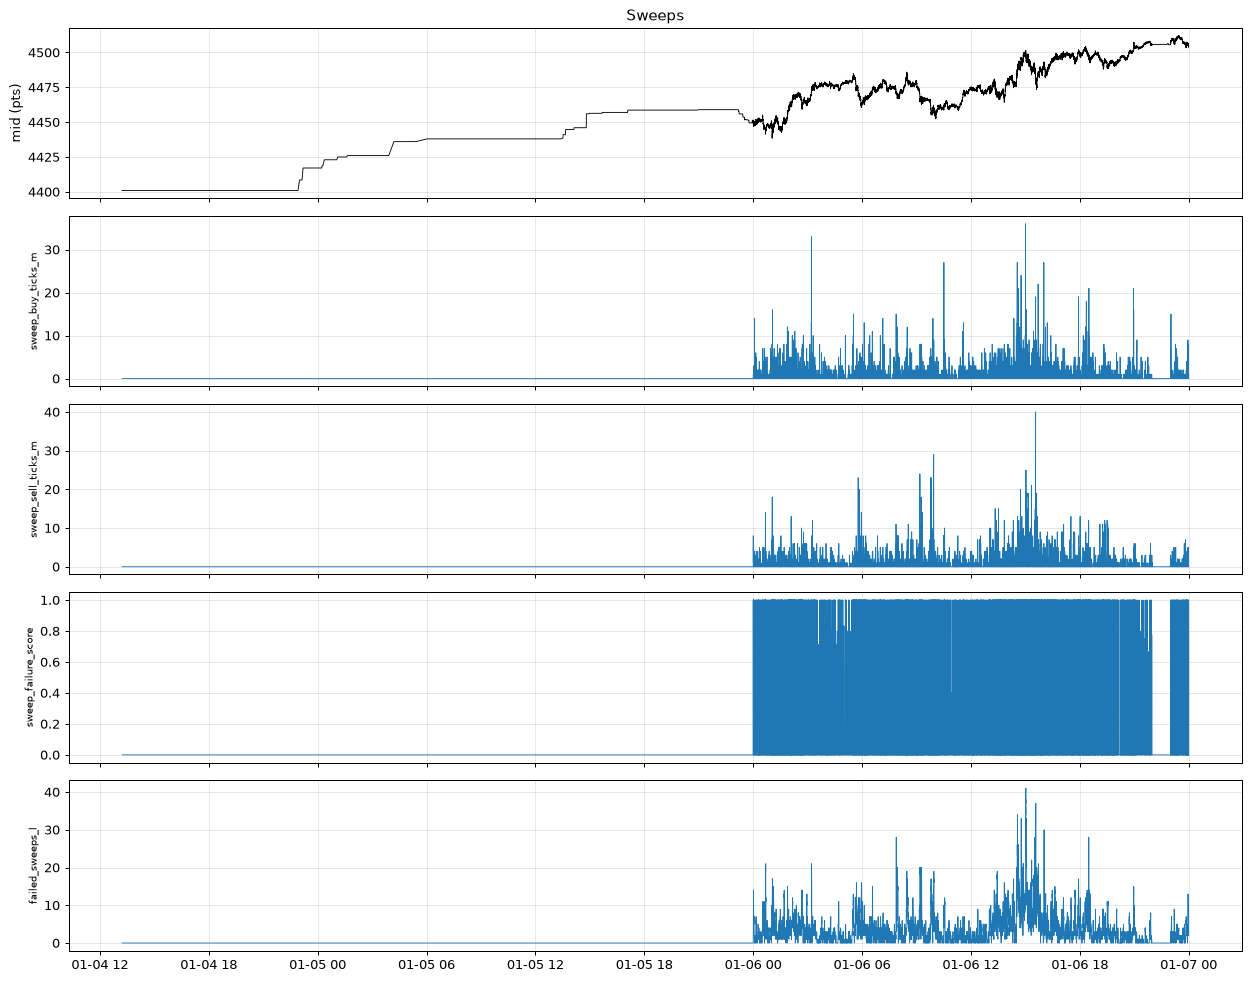

In [11]:
panel(["sweep_buy_ticks_m", "sweep_sell_ticks_m", "sweep_failure_score", "failed_sweeps_l"], "Sweeps")

## Queue Depletion + Queue Turnover

Sanity: [0,1); depletion spikes with executions at the touch; turnover reflects churn even without executions.

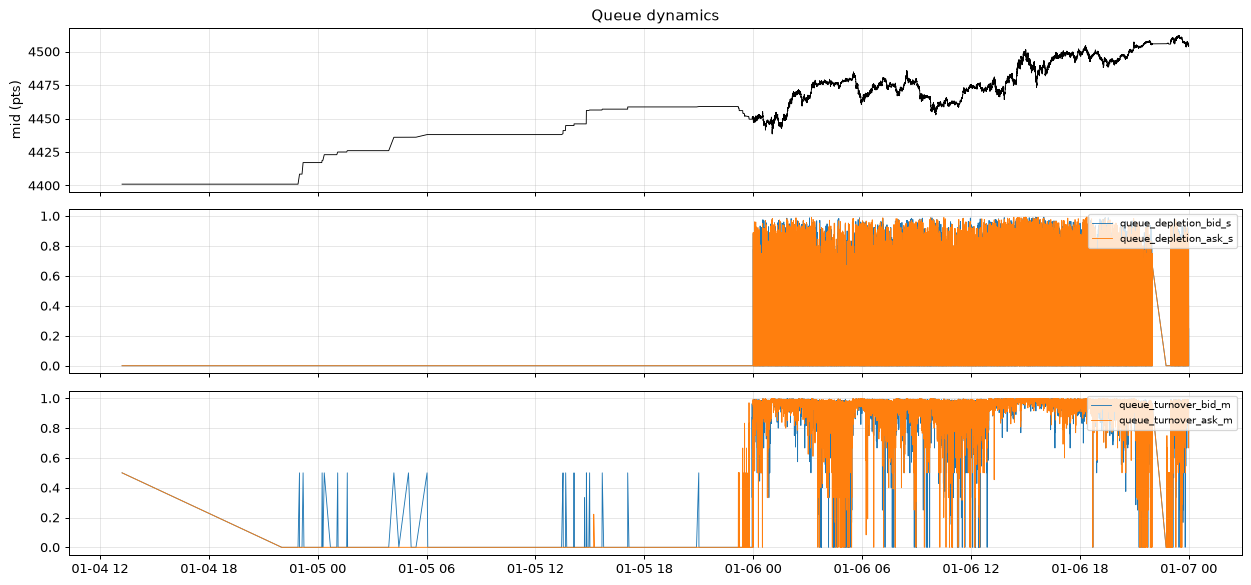

In [12]:
panel([("queue_depletion_bid_s","queue_depletion_ask_s"), ("queue_turnover_bid_m","queue_turnover_ask_m")], "Queue dynamics")

## Order Survival + Cancel-before-touch (Phase 2 lifecycle)

Sanity: ratios in [0,1], slow-moving (60s window), neutral 0.5 only during inactivity.

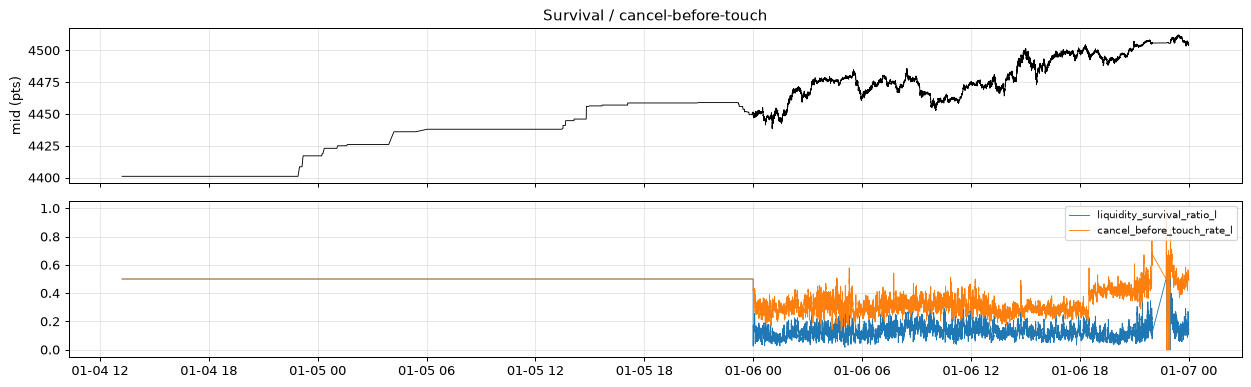

In [13]:
panel([("liquidity_survival_ratio_l","cancel_before_touch_rate_l")], "Survival / cancel-before-touch")

## Iceberg score (heuristic; Critical Rule 8)

Sanity: [0,1); episodic — driven by refill links and hidden executions; must NOT sit at a constant high value.

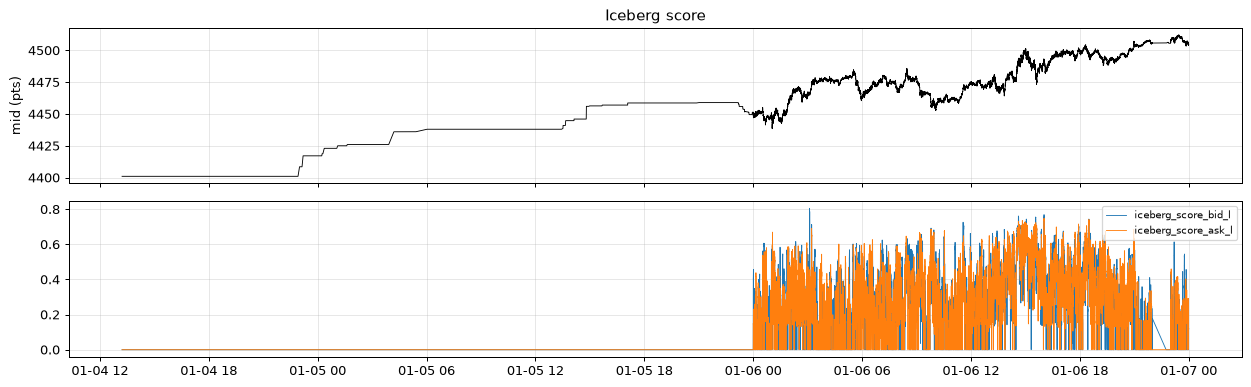

In [14]:
panel([("iceberg_score_bid_l","iceberg_score_ask_l")], "Iceberg score")

## Liquidity Vacuum + Book Resiliency

Sanity: vacuum ~0.5 at baseline depth, spikes when near-touch depth vanishes; resiliency pinned near 1 except after depletion episodes.

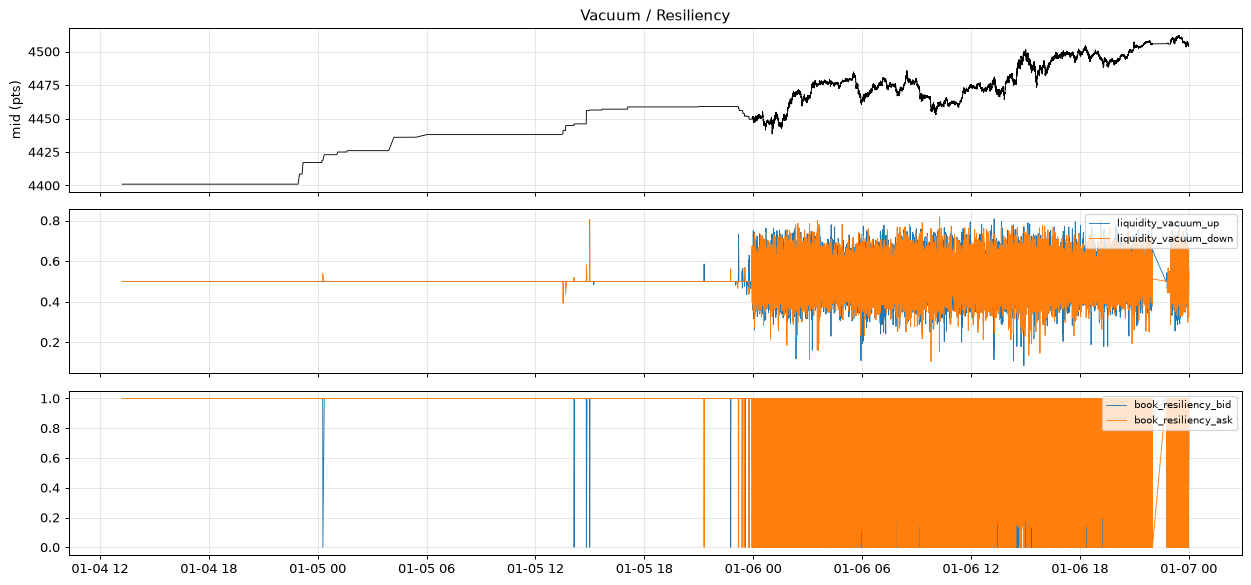

In [15]:
panel([("liquidity_vacuum_up","liquidity_vacuum_down"), ("book_resiliency_bid","book_resiliency_ask")], "Vacuum / Resiliency")

## Trade Burst Intensity

Sanity: 0.5 = average intensity; bursts push toward 1; quiet stretches toward 0.

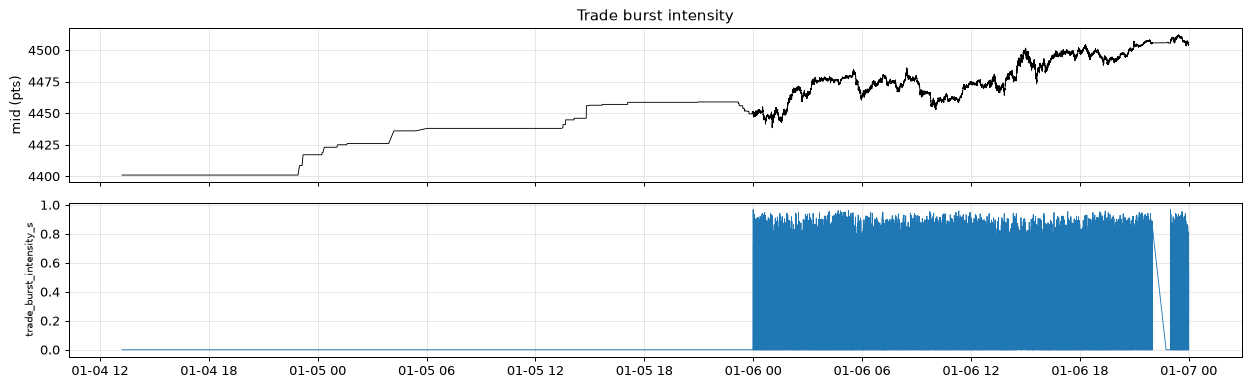

In [16]:
panel(["trade_burst_intensity_s"], "Trade burst intensity")

## Order Lifetime (raw vs chain-adjusted) + Liquidity Age

Sanity: chain-adjusted lifetime >= raw (refill clips excluded); liquidity age drops when the touch turns over.

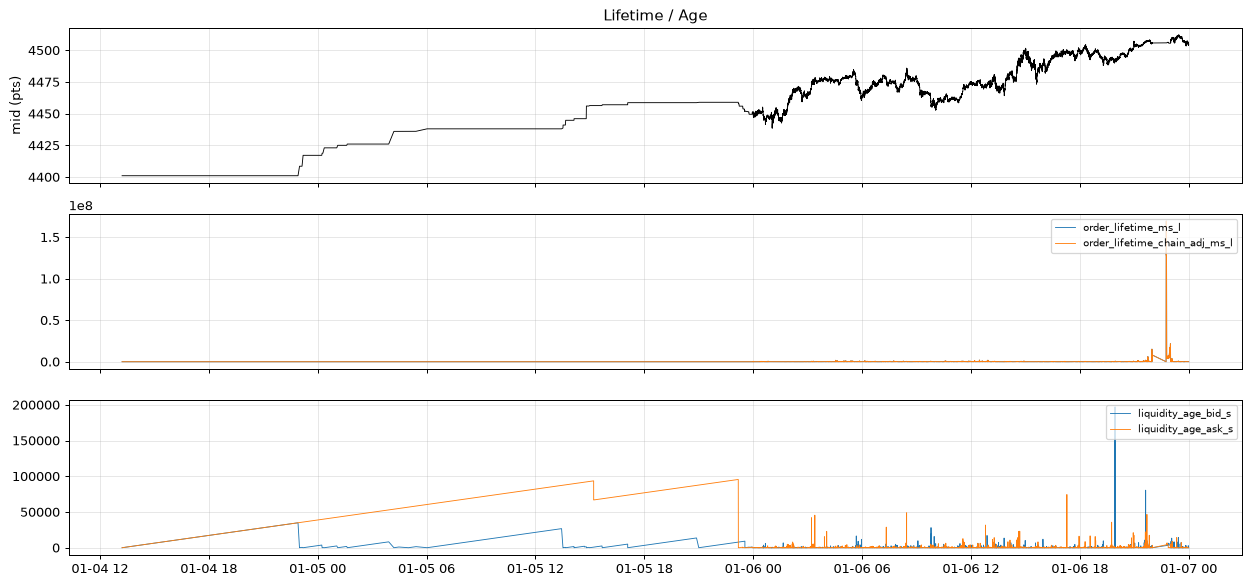

In [17]:
panel([("order_lifetime_ms_l","order_lifetime_chain_adj_ms_l"), ("liquidity_age_bid_s","liquidity_age_ask_s")], "Lifetime / Age")